- Import Section


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor , plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

- Utility Functions & Data Splitting


In [2]:
def evaluate_model(y_true, y_predicted, model_name):
    y_true = np.array(y_true).flatten()
    y_predicted = np.array(y_predicted).flatten()
    
    print(f"Model: {model_name}")
    print(f"MAE: {mean_absolute_error(y_true, y_predicted)}")
    print(f"MSE: {mean_squared_error(y_true, y_predicted)}")
    print(f"R² Score: {r2_score(y_true, y_predicted)}")
    print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_true, y_predicted))}")


In [14]:
def plot_actual_vs_predicted(y_true, y_predicted, model_name):

    y_true = np.array(y_true).flatten()
    y_predicted = np.array(y_predicted).flatten()

    plt.figure(figsize=(10,6))
    plt.scatter(y_true, y_predicted, color='blue', alpha=0.5)
    
    min_val = min(y_true.min(), y_predicted.min())
    max_val = max(y_true.max(), y_predicted.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")  # reference line
    plt.xlabel("Actual values")
    plt.ylabel("Predicted values")
    plt.title(f"{model_name} - Actual vs Predicted")
    plt.show()


In [6]:
def plot_residuals(y_true, y_predicted, model_name):
    
    if isinstance(y_true, pd.DataFrame):
        y_true = y_true.squeeze()  # convert to Series if it's a DataFrame

    # compute residuals
    residuals = y_true - y_predicted

    # plot residuals
    plt.figure(figsize=(10, 10))
    plt.scatter(y_predicted, residuals, color="purple", alpha=0.5)
    plt.axhline(y=0, color="red", linestyle="--")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals (Errors)")
    plt.title(f"{model_name} - Residual Plot")
    plt.grid()
    plt.show()


In [ ]:
def plot_residual_histogram(y_true, y_predicted, model_name):
    y_true = y_true.squeeze()
    residuals = y_true - y_predicted
    # fit a normal distribution to the residuals
    mu, sigma = np.mean(residuals), np.std(residuals)
    # generate x values for normal distribution curve
    x = np.linspace(min(residuals), max(residuals), 100)
    pdf = stats.norm.pdf(x, mu, sigma)
    # plot histogram
    plt.figure(figsize=(8, 6))
    plt.hist(residuals, bins=30, color='purple', alpha=0.7, edgecolor='black', density=True)
    # overlay normal distribution curve
    plt.plot(x, pdf, color='red', linewidth=2, label="Normal Distribution")

    plt.xlabel("Residuals (Errors)")
    plt.ylabel("Density")
    plt.title(f"{model_name} - Residual Histogram with Normal Distribution")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
from tabulate import tabulate

def plot_feature_importance(model, feature_names):
    importance = model.feature_importances_  
    feature_importance = pd.DataFrame({
        "Feature": feature_names, 
        "Importance (%)": importance * 100 
    })
    feature_importance = feature_importance.sort_values(by="Importance (%)", ascending=False)
    print(tabulate(feature_importance, headers="keys", tablefmt="fancy_grid", showindex=False))
    # get features with importance > 0%
    important_features = feature_importance[feature_importance["Importance (%)"] >0]
    plt.figure(figsize=(10, 12))  
    sns.barplot(x="Importance (%)", y="Feature", data=feature_importance, palette="viridis")
    
    #  percentage labels
    for index, value in enumerate(feature_importance["Importance (%)"]):
        plt.text(value + 0.5, index, f"{value:.2f}%", va="center")

    plt.title("Feature Importance (%)")
    plt.xlabel("Importance (%)")
    plt.ylabel("Feature Name")
    plt.show()

    return important_features["Feature"].tolist() 


In [9]:
X_train = pd.read_csv("x_train.csv",index_col=0)
y_train = pd.read_csv("y_train.csv" ,index_col=0)

X_test = pd.read_csv("x_test.csv",index_col=0)
y_test = pd.read_csv("y_test.csv",index_col=0)

# Decision Tree


- Train the model


In [10]:
DecisionTreeModel=DecisionTreeRegressor()
DecisionTreeModel.fit(X_train, y_train)

DecisionTreeRegressor()

plot the decision tree


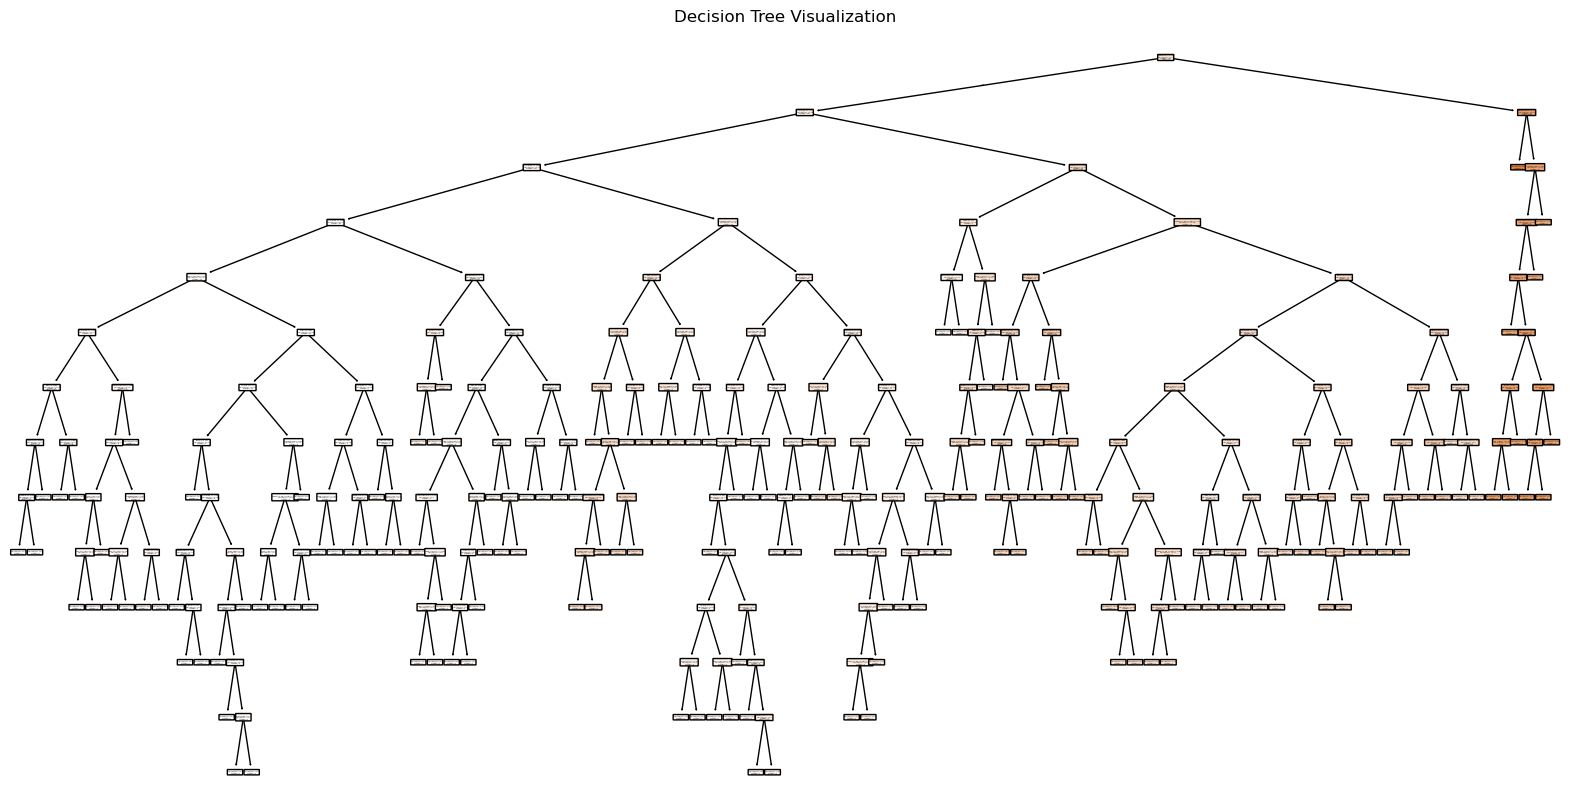

In [47]:
plt.figure(figsize=(20, 10))  # Adjust figure size for readability
plot_tree(DecisionTreeModel, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

In [12]:
y_predicted_dt=DecisionTreeModel.predict(X_test)

In [13]:
evaluate_model(y_test,y_predicted_dt,"DecisionTreeRegressor")

Model: DecisionTreeRegressor
MAE: 0.21139313204055654
MSE: 0.09622832635186788
R² Score: 0.9316585841803865
Root Mean Squared Error (RMSE): 0.31020690893638697


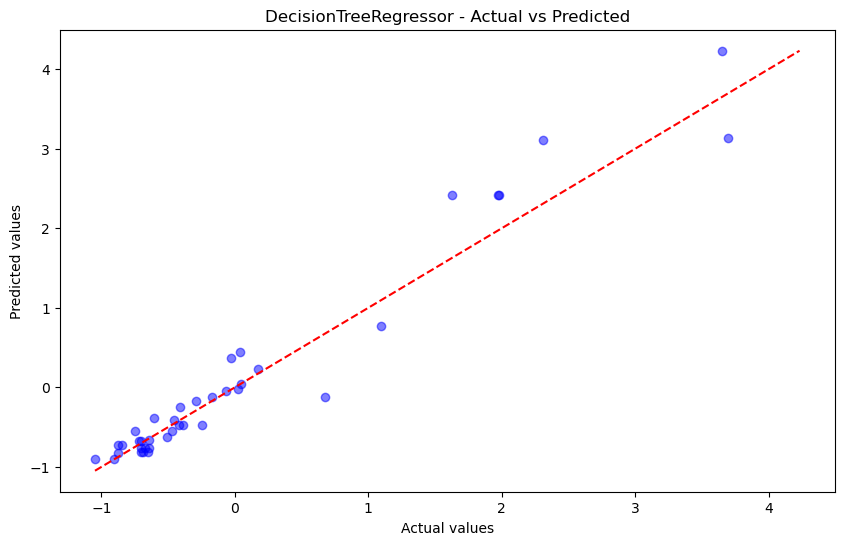

In [15]:
plot_actual_vs_predicted(y_test,y_predicted_dt,"DecisionTreeRegressor")

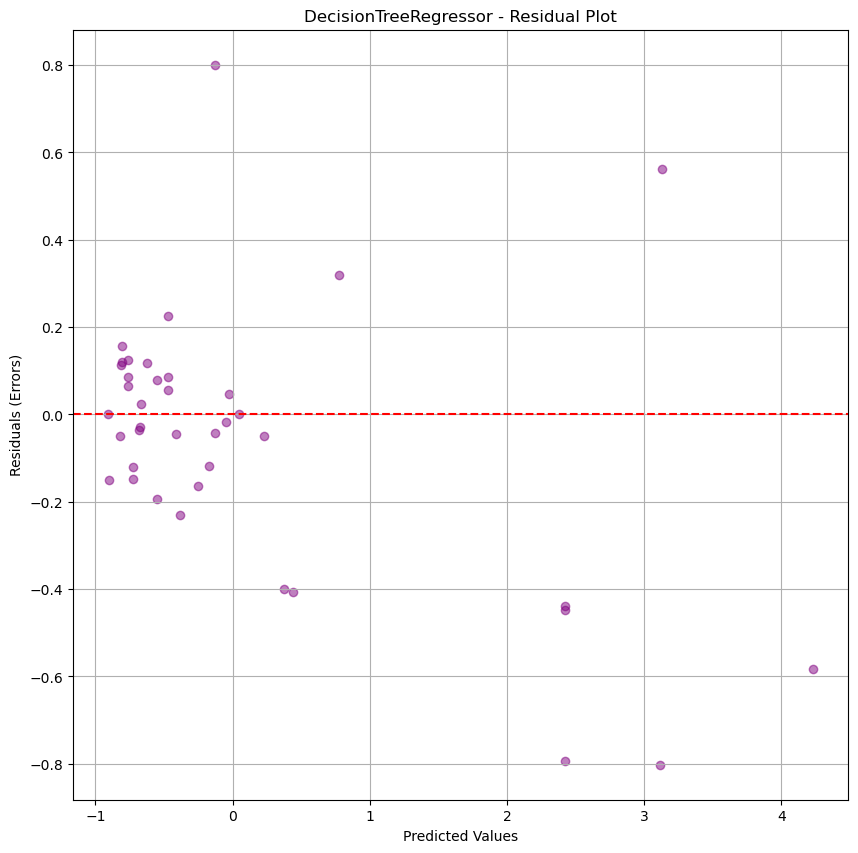

In [16]:
plot_residuals(y_test,y_predicted_dt,"DecisionTreeRegressor")

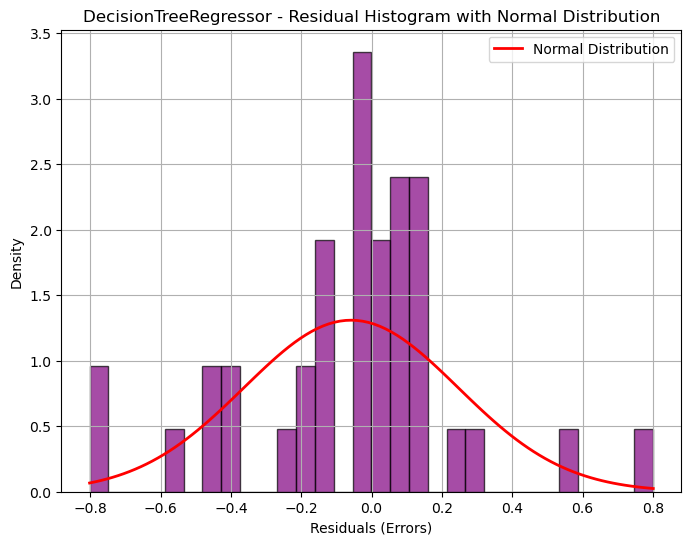

In [18]:

plot_residual_histogram(y_test,y_predicted_dt,"DecisionTreeRegressor")

╒══════════════════════════╤══════════════════╕
│ Feature                  │   Importance (%) │
╞══════════════════════════╪══════════════════╡
│ engine-size              │     64.0004      │
├──────────────────────────┼──────────────────┤
│ curb-weight              │     27.3685      │
├──────────────────────────┼──────────────────┤
│ highway-mpg              │      2.01421     │
├──────────────────────────┼──────────────────┤
│ combined_mpg             │      1.27888     │
├──────────────────────────┼──────────────────┤
│ engine_size_per_cylinder │      0.883507    │
├──────────────────────────┼──────────────────┤
│ bore                     │      0.606859    │
├──────────────────────────┼──────────────────┤
│ peak-rpm                 │      0.561382    │
├──────────────────────────┼──────────────────┤
│ power_to_weight          │      0.510628    │
├──────────────────────────┼──────────────────┤
│ city-mpg                 │      0.427779    │
├──────────────────────────┼────────────

C:\Users\dell\AppData\Local\Temp\ipykernel_7864\3648721288.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance (%)", y="Feature", data=feature_importance, palette="viridis")


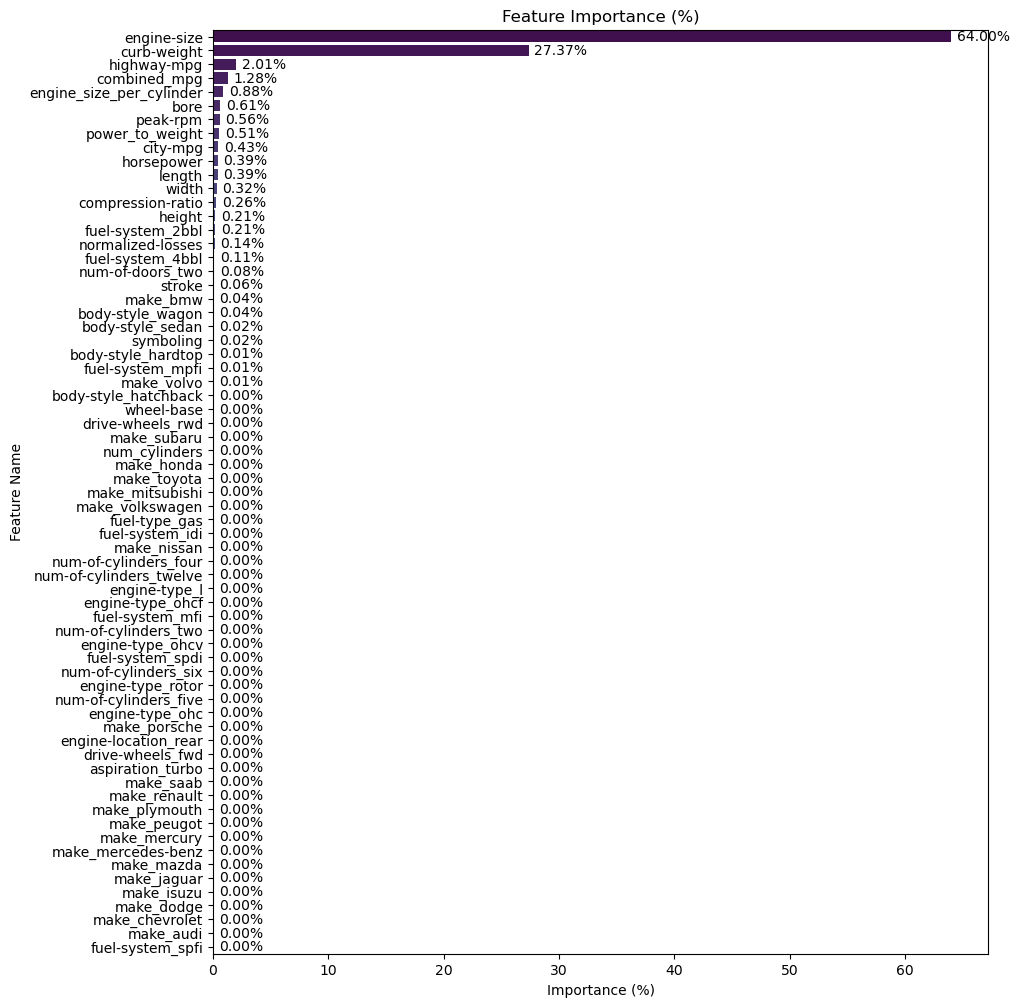

In [43]:
important_feature=plot_feature_importance(DecisionTreeModel,X_train.columns)

In [89]:
print(important_feature)
print(len(important_feature))

['engine-size', 'curb-weight', 'highway-mpg', 'combined_mpg', 'width', 'horsepower', 'wheel-base', 'engine_size_per_cylinder', 'length', 'num_cylinders', 'make_bmw', 'power_to_weight', 'peak-rpm', 'normalized-losses', 'bore', 'city-mpg', 'height', 'compression-ratio', 'stroke', 'engine-type_ohc', 'body-style_sedan', 'drive-wheels_rwd', 'fuel-system_mpfi', 'aspiration_turbo', 'make_audi', 'symboling', 'make_volvo', 'fuel-system_2bbl', 'drive-wheels_fwd', 'num-of-doors_two', 'body-style_hardtop', 'body-style_hatchback', 'fuel-system_idi', 'engine-type_ohcf', 'make_toyota', 'body-style_wagon', 'num-of-cylinders_six', 'make_plymouth', 'num-of-cylinders_four', 'make_mazda', 'num-of-cylinders_two', 'fuel-type_gas', 'make_mercedes-benz', 'make_volkswagen', 'fuel-system_4bbl', 'make_mitsubishi', 'make_saab', 'fuel-system_spdi', 'make_nissan', 'engine-type_ohcv', 'engine-type_rotor', 'make_porsche', 'make_renault', 'make_subaru', 'num-of-cylinders_five', 'make_jaguar', 'engine-type_l', 'make_me

- cross validation of untuned decision tree


In [61]:
from sklearn.model_selection import cross_val_score
dt = DecisionTreeRegressor(random_state=42)
cv_scores = cross_val_score(dt, X_train, y_train, cv=10, scoring="neg_mean_squared_error")  #10-fold CV
mse_scores = -cv_scores  
rmse_scores = np.sqrt(mse_scores)  
std_mse = np.std(mse_scores)
print("Cross-Validation MSE Scores:", mse_scores)
print("Mean MSE:", np.mean(mse_scores))
print("MSE Standard Deviation:", std_mse)
print("Mean RMSE:", np.mean(rmse_scores))


Cross-Validation MSE Scores: [0.0761997  0.15111093 0.04207536 0.10764887 0.45755938 0.22786001
 0.16298591 0.11893213 0.17640186 0.23471804]
Mean MSE: 0.17554921966771428
MSE Standard Deviation: 0.11046467459176663
Mean RMSE: 0.40048325087207653


The Decision Tree model has a Mean MSE of 0.1755 and RMSE of 0.4005 indicating a reasonable but not optimal error rate

- High Variance Across Folds \* indicates that the model is not very stable and may not generalize well to unseen data ( the model may be overfitting to some training subsets)  
  Need for improvement we may see hyparameter tuning or random forest (it can help reduce the variance and improve the model's stability)


- hyparameter tuning (Grid Search)


In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
import numpy as np

#  Select only important features
X_train_selected = X_train[important_feature]  
X_test_selected = X_test[important_feature]    

dt = DecisionTreeRegressor(random_state=42)

# define hyperparameter grid
param_grid = {
    "max_depth": np.arange(1, 15),  # 1 to 14 
    "min_samples_split": np.arange(2, 17, 2),  # even numbers from 2 to 16 (~10% OF total samples)
    "min_samples_leaf": np.arange(1, 9, 2)  # odd numbers from 1 to 7 (~5% of total samples)
}

# prform Grid Search with Cross Validation
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train_selected, y_train)  

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)
print("Best Model:", best_model)


Best Parameters: {'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 10}
Best Model: DecisionTreeRegressor(max_depth=6, min_samples_leaf=3, min_samples_split=10,
                      random_state=42)


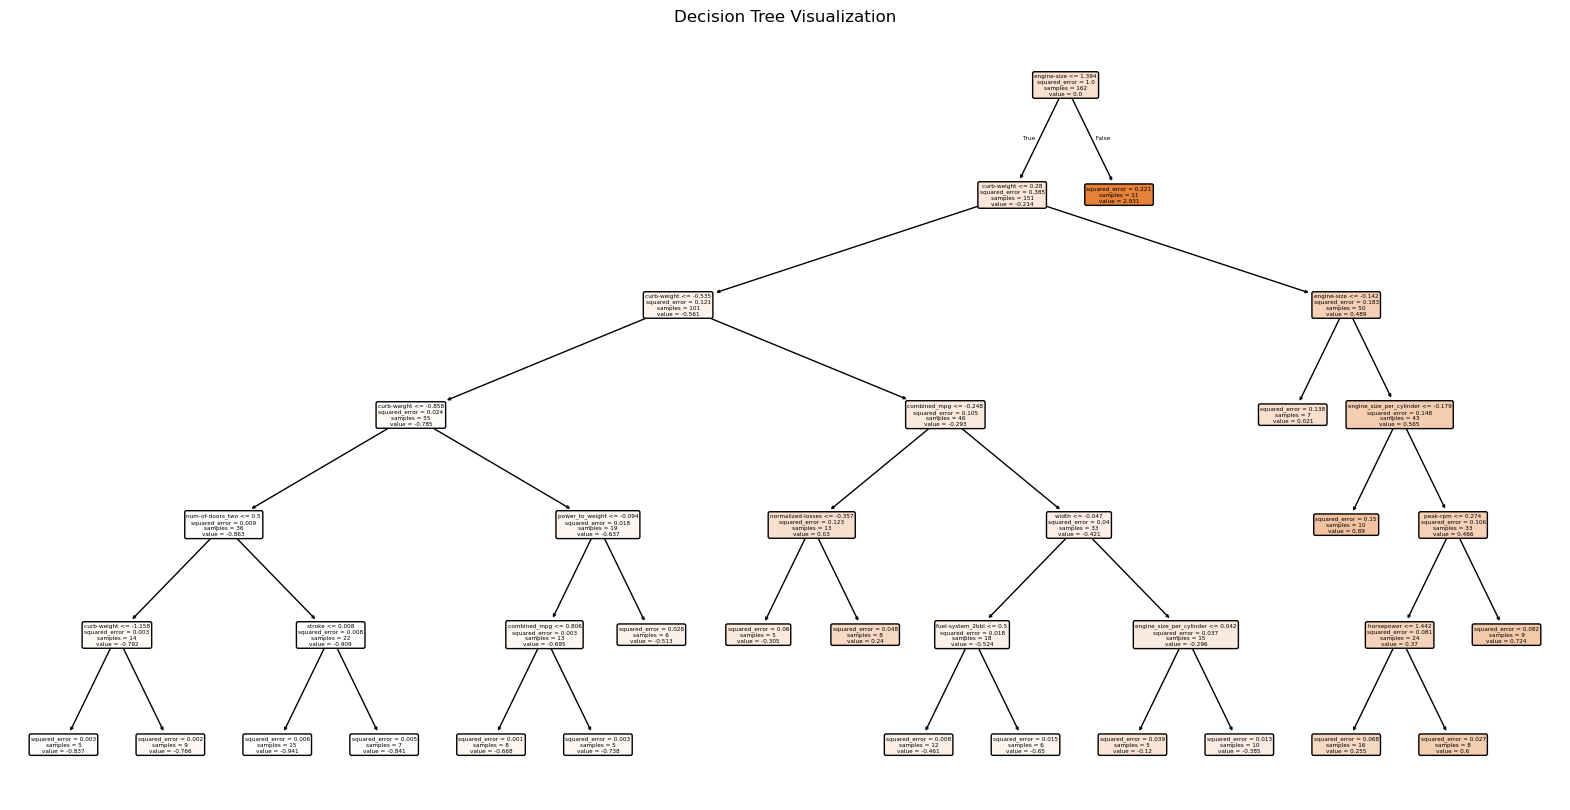

In [78]:
plt.figure(figsize=(20, 10))  # Adjust figure size for readability
plot_tree(best_model, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

In [59]:
y_predicted_dt_hyp=best_model.predict(X_test[important_feature])
evaluate_model(y_test,y_predicted_dt_hyp,"DecisionTreeRegressor with hyparameter tuning {'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 12} and important features")


Model: DecisionTreeRegressor with hyparameter tuning {'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 12} and important features
MAE: 0.28118293271300254
MSE: 0.17569078308465155
R² Score: 0.8752242991470398
Root Mean Squared Error (RMSE): 0.419154843804353


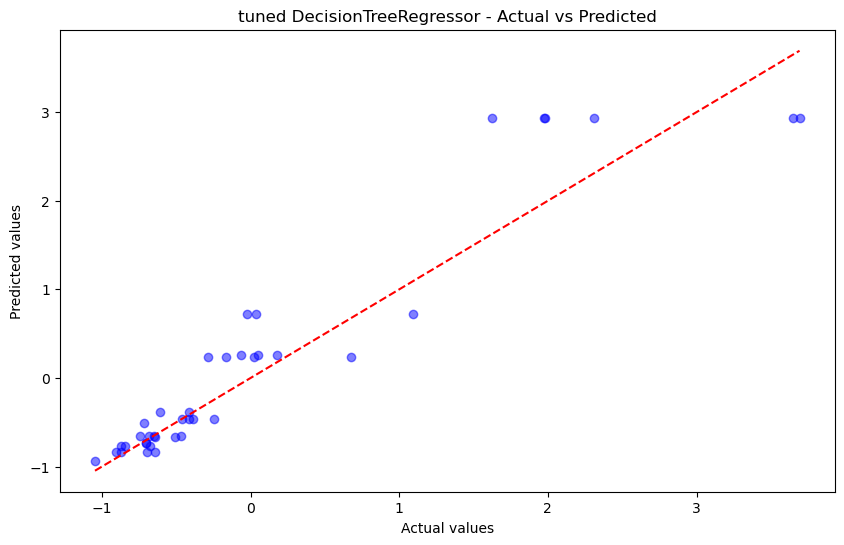

In [81]:
plot_actual_vs_predicted(y_test,y_predicted_dt_hyp,"tuned DecisionTreeRegressor")

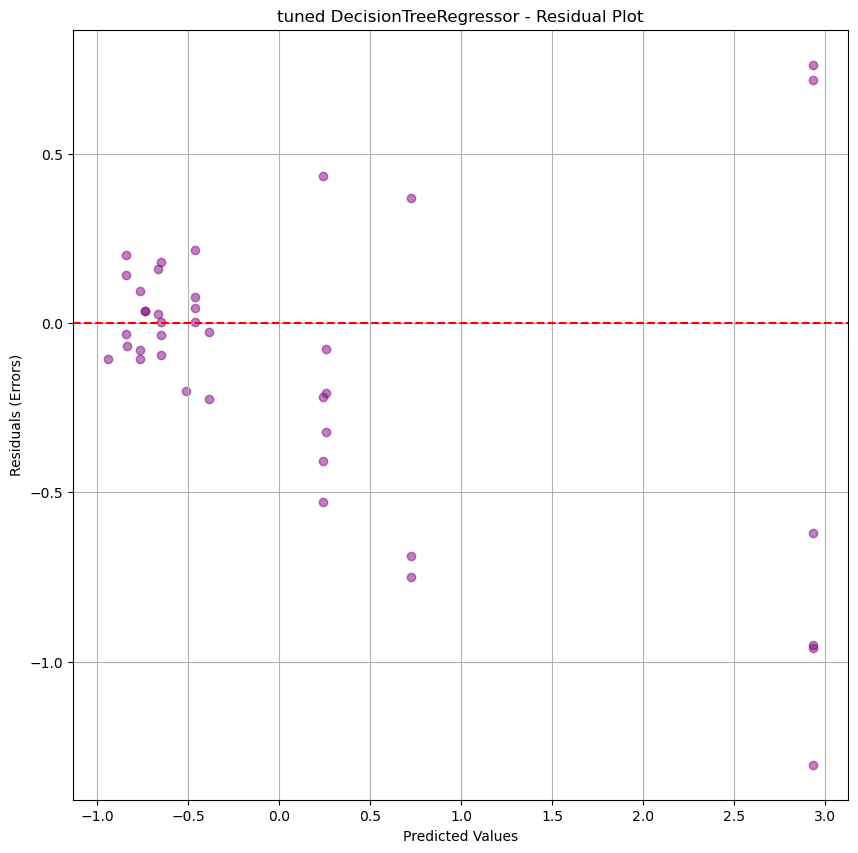

In [82]:
plot_residuals(y_test,y_predicted_dt_hyp,"tuned DecisionTreeRegressor")

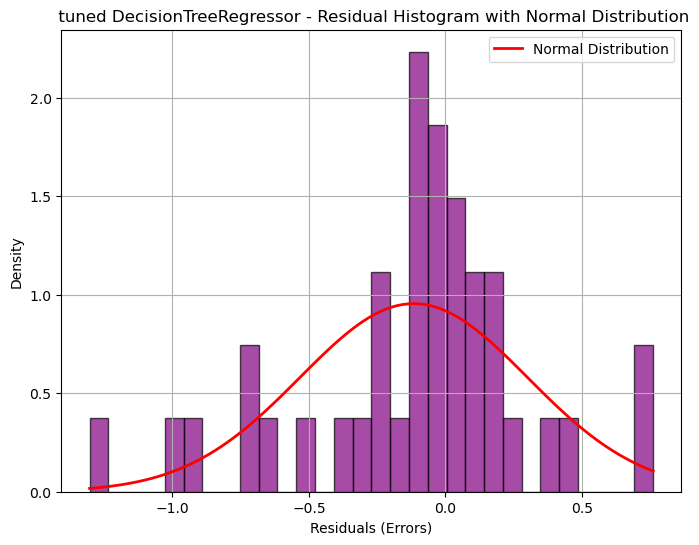

In [83]:

plot_residual_histogram(y_test,y_predicted_dt_hyp," tuned DecisionTreeRegressor")

╒══════════════════════════╤══════════════════╕
│ Feature                  │   Importance (%) │
╞══════════════════════════╪══════════════════╡
│ engine-size              │       67.2026    │
├──────────────────────────┼──────────────────┤
│ curb-weight              │       28.3905    │
├──────────────────────────┼──────────────────┤
│ combined_mpg             │        1.24529   │
├──────────────────────────┼──────────────────┤
│ engine_size_per_cylinder │        1.05205   │
├──────────────────────────┼──────────────────┤
│ normalized-losses        │        0.594678  │
├──────────────────────────┼──────────────────┤
│ peak-rpm                 │        0.535058  │
├──────────────────────────┼──────────────────┤
│ horsepower               │        0.414578  │
├──────────────────────────┼──────────────────┤
│ width                    │        0.27655   │
├──────────────────────────┼──────────────────┤
│ fuel-system_2bbl         │        0.0929132 │
├──────────────────────────┼────────────

C:\Users\dell\AppData\Local\Temp\ipykernel_7864\3648721288.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance (%)", y="Feature", data=feature_importance, palette="viridis")


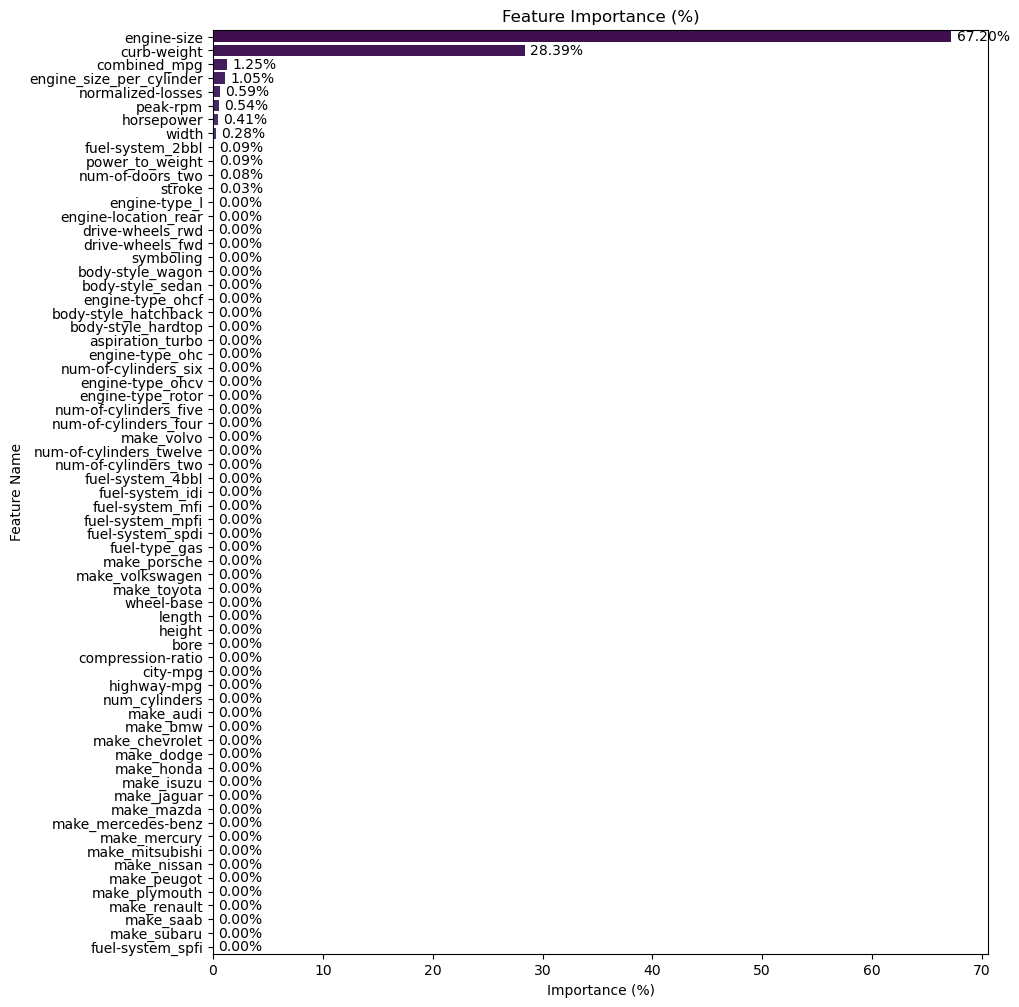

In [84]:
important_feature_tuned=plot_feature_importance(best_model,X_train.columns)

In [90]:
print(important_feature_tuned)
print(len(important_feature_tuned))

['engine-size', 'curb-weight', 'combined_mpg', 'engine_size_per_cylinder', 'normalized-losses', 'peak-rpm', 'horsepower', 'width', 'fuel-system_2bbl', 'power_to_weight', 'num-of-doors_two', 'stroke']
12


- cross validation for the tuned model


In [63]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Perform 5-Fold Cross-Validation on the best model
cv_mse_scores = -cross_val_score(best_model, X_train_selected, y_train, cv=10, scoring="neg_mean_squared_error")

# Compute the mean and standard deviation of MSE
mean_mse = np.mean(cv_mse_scores)
std_mse = np.std(cv_mse_scores)
print("Cross-Validation MSE Scores:", cv_mse_scores)
print("Mean MSE:", mean_mse)
print("MSE Standard Deviation:", std_mse)
print("Mean RMSE:", np.sqrt(mean_mse))


Cross-Validation MSE Scores: [0.10999258 0.05461189 0.06450426 0.08398421 0.32782119 0.1998309
 0.0808003  0.14246641 0.09733924 0.23159116]
Mean MSE: 0.1392942121792864
MSE Standard Deviation: 0.08342665922047936
Mean RMSE: 0.3732213983405646


Conclusion:  
The first model, without tuning, performs better in terms of accuracy,but it exhibits overfitting, as indicated by its higher variance across cross-validation folds  
On the other hand, the tuned DecisionTreeRegressor with feature selection is more stable and generalizes better, even though its accuracy is slightly lower  
Since stability is crucial for real-world applications, the tuned model is preferred  
Further improvements could be made by using ensemble methods to find a balance between accuracy and stability


# Random Forest


- train the model


In [64]:
RandomForestModel=RandomForestRegressor()
RandomForestModel.fit(X_train,y_train)

c:\Users\dell\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

visualize some trees from the random forest model


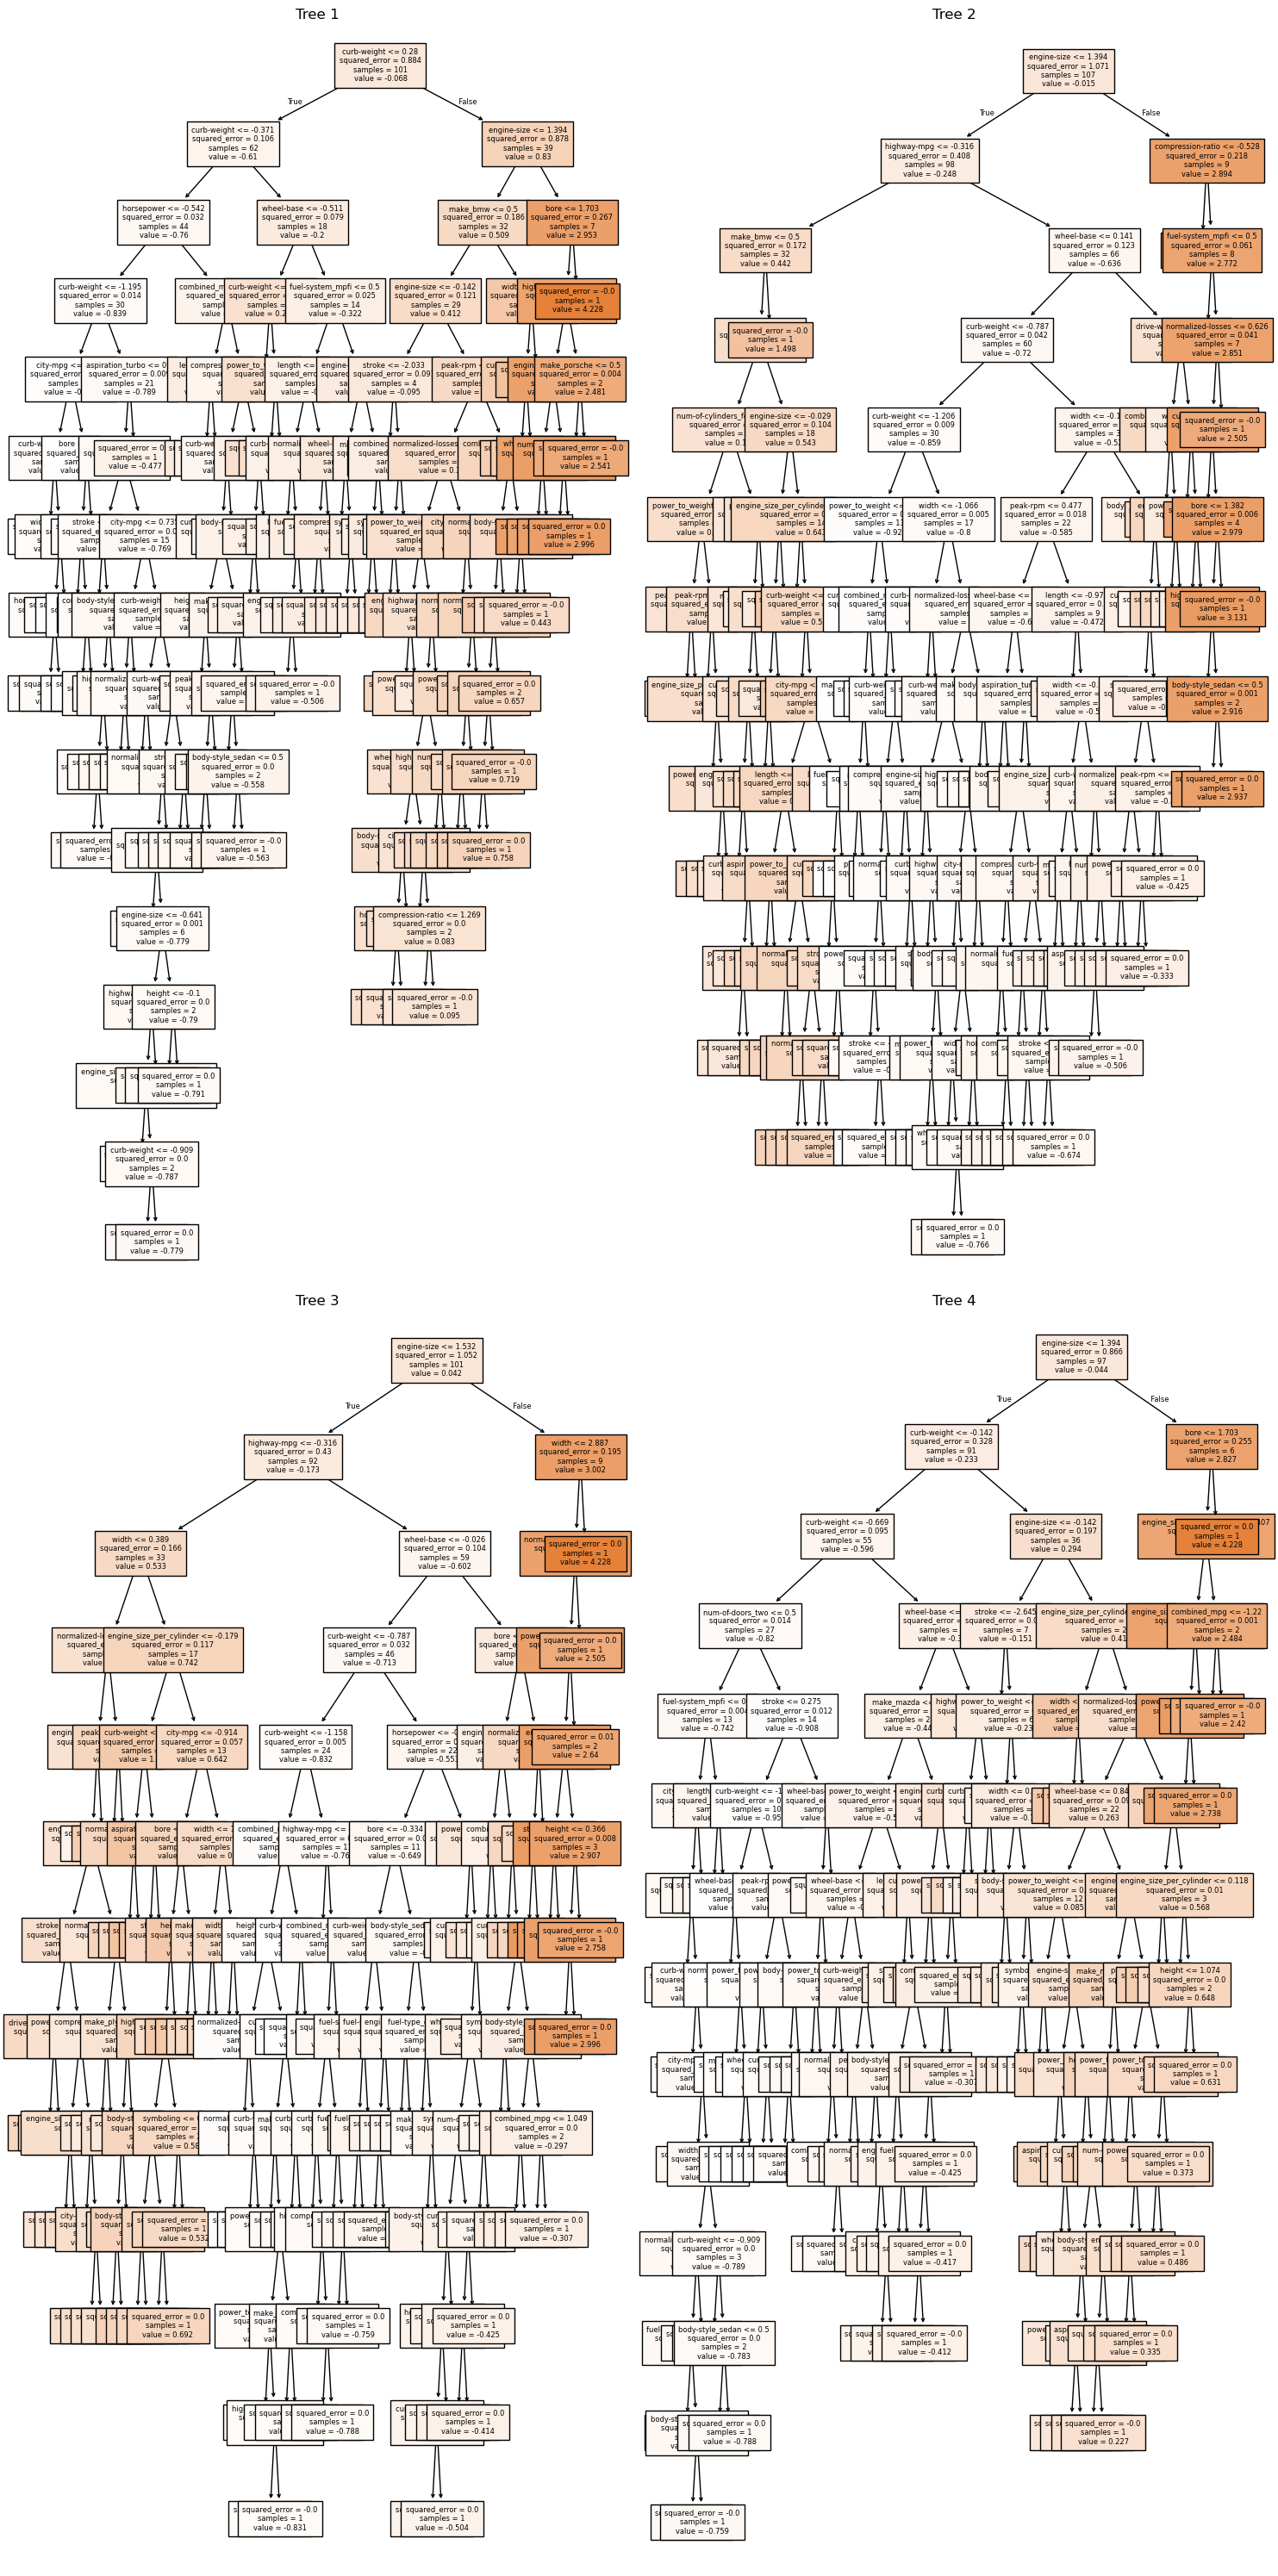

In [68]:
n_trees=4
fig,axes=plt.subplots(2, 2, figsize=(15, 30))
for i , ax in enumerate(axes.flat):
    plot_tree(RandomForestModel.estimators_[i],filled=True, feature_names=X_train.columns, ax=ax, fontsize=6)
    ax.set_title(f"Tree {i+1}")
plt.tight_layout()
plt.show()

In [93]:
max_depth = max(tree.get_depth() for tree in RandomForestModel.estimators_)
print("Maximum Tree Depth:", max_depth)


Maximum Tree Depth: 17


- prediction


In [70]:
y_predicted_rf=RandomForestModel.predict(X_test)

- Evaluation of the model


In [72]:
evaluate_model(y_test,y_predicted_rf ,"RandomForestRegressor")

Model: RandomForestRegressor
MAE: 0.1737888786571339
MSE: 0.05940423316524063
R² Score: 0.9578110775267351
Root Mean Squared Error (RMSE): 0.24372983642804305


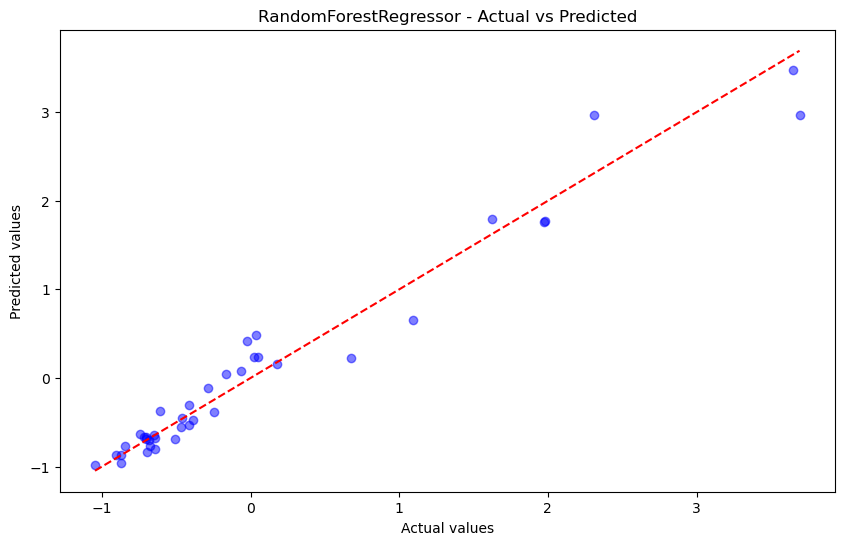

In [74]:
plot_actual_vs_predicted(y_test,y_predicted_rf,"RandomForestRegressor")

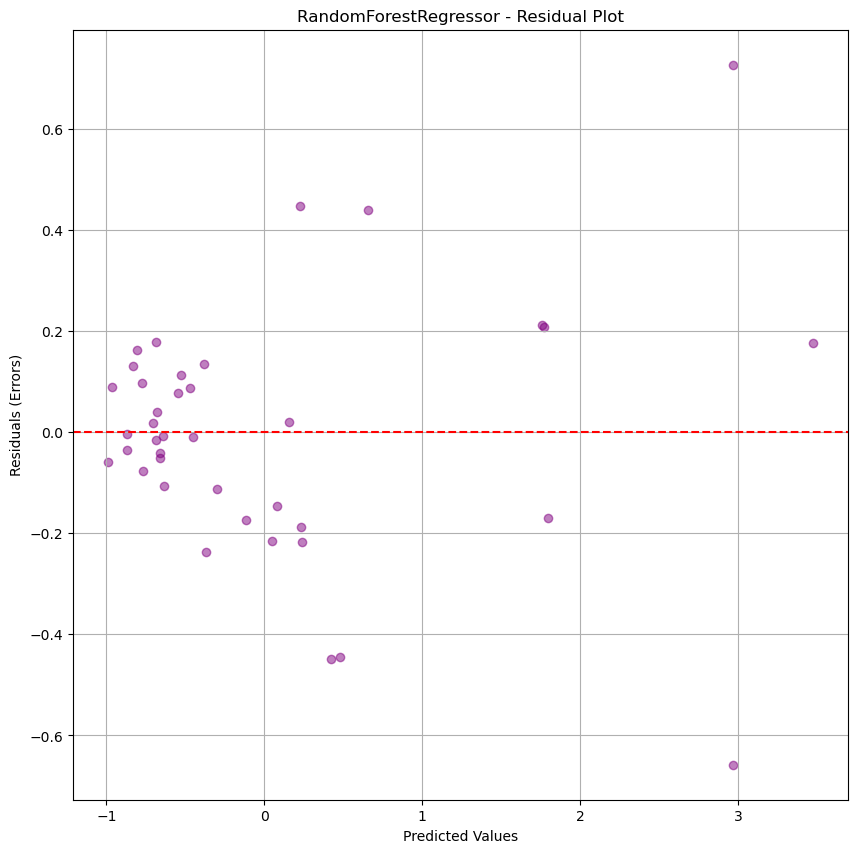

In [75]:
plot_residuals(y_test,y_predicted_rf,"RandomForestRegressor")

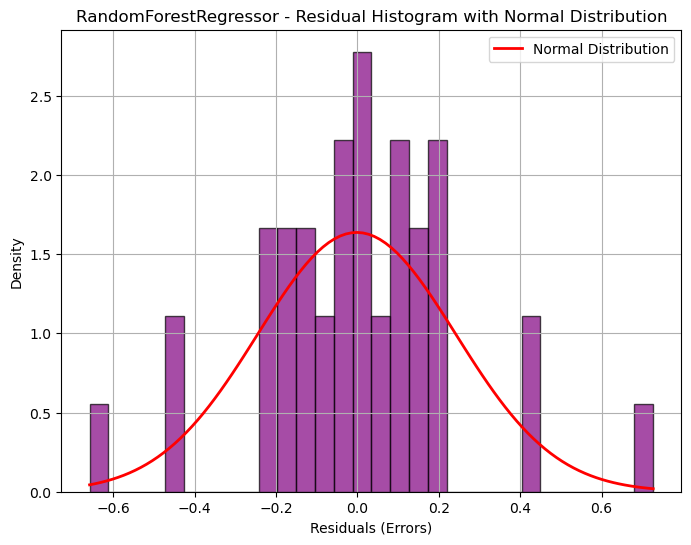

In [76]:

plot_residual_histogram(y_test,y_predicted_rf,"RandomForestRegressor")

╒══════════════════════════╤══════════════════╕
│ Feature                  │   Importance (%) │
╞══════════════════════════╪══════════════════╡
│ engine-size              │     57.4111      │
├──────────────────────────┼──────────────────┤
│ curb-weight              │     22.7438      │
├──────────────────────────┼──────────────────┤
│ highway-mpg              │      4.41666     │
├──────────────────────────┼──────────────────┤
│ combined_mpg             │      4.38862     │
├──────────────────────────┼──────────────────┤
│ width                    │      1.90738     │
├──────────────────────────┼──────────────────┤
│ horsepower               │      1.2919      │
├──────────────────────────┼──────────────────┤
│ wheel-base               │      0.980203    │
├──────────────────────────┼──────────────────┤
│ engine_size_per_cylinder │      0.785258    │
├──────────────────────────┼──────────────────┤
│ length                   │      0.66521     │
├──────────────────────────┼────────────

C:\Users\dell\AppData\Local\Temp\ipykernel_7864\3648721288.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance (%)", y="Feature", data=feature_importance, palette="viridis")


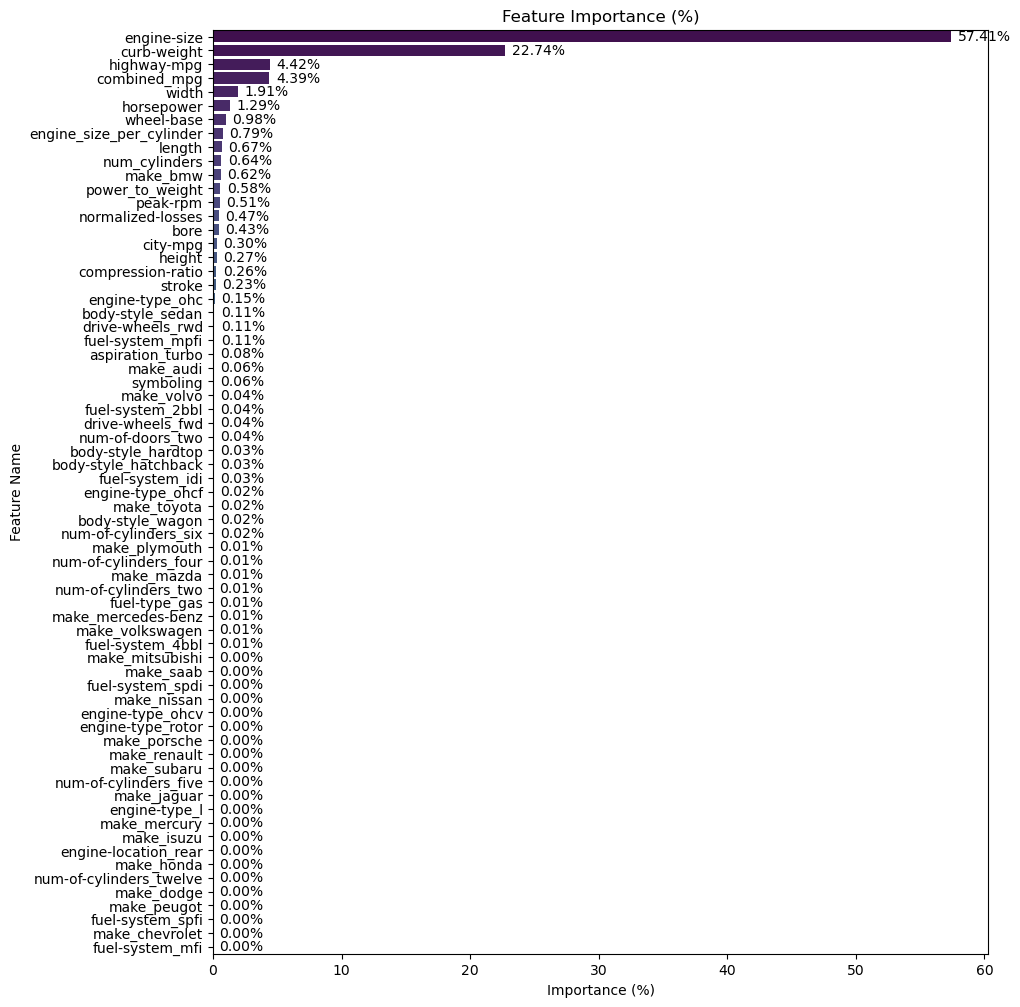

In [86]:
important_feature_rf=plot_feature_importance(RandomForestModel,X_train.columns)

In [91]:
for i in range(0, len(important_feature_rf), 5):  # Adjust chunk size
    print(", ".join(important_feature_rf[i:i+5]))


engine-size, curb-weight, highway-mpg, combined_mpg, width
horsepower, wheel-base, engine_size_per_cylinder, length, num_cylinders
make_bmw, power_to_weight, peak-rpm, normalized-losses, bore
city-mpg, height, compression-ratio, stroke, engine-type_ohc
body-style_sedan, drive-wheels_rwd, fuel-system_mpfi, aspiration_turbo, make_audi
symboling, make_volvo, fuel-system_2bbl, drive-wheels_fwd, num-of-doors_two
body-style_hardtop, body-style_hatchback, fuel-system_idi, engine-type_ohcf, make_toyota
body-style_wagon, num-of-cylinders_six, make_plymouth, num-of-cylinders_four, make_mazda
num-of-cylinders_two, fuel-type_gas, make_mercedes-benz, make_volkswagen, fuel-system_4bbl
make_mitsubishi, make_saab, fuel-system_spdi, make_nissan, engine-type_ohcv
engine-type_rotor, make_porsche, make_renault, make_subaru, num-of-cylinders_five
make_jaguar, engine-type_l, make_mercury, make_isuzu, engine-location_rear
make_honda, num-of-cylinders_twelve, make_dodge, make_peugot, fuel-system_spfi
make_che

In [92]:

print(len(important_feature_rf))


67


- cross validation


In [73]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation with 5 folds
cv_mse = -cross_val_score(RandomForestModel, X_train, y_train, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)

# Print cross-validation results
print("Cross-Validation MSE Scores:", cv_mse)
print("MSE standard deviation ",np.std(cv_mse))
print("Mean MSE:", np.mean(cv_mse))
print("Mean RMSE:", np.sqrt(np.mean(cv_mse)))


Cross-Validation MSE Scores: [0.07168696 0.0940053  0.04033453 0.03668538 0.24690727 0.11365535
 0.06639593 0.07169952 0.0482282  0.258104  ]
MSE standard deviation  0.07717142080173553
Mean MSE: 0.10477024435537459
Mean RMSE: 0.32368232011553333


we can see that the accuracy of random forest regressor is better than untuned and tuned decision tree and more stable than both


- hyparameter tuning


In [94]:
param_grid = {
    'n_estimators': [10, 50, 100],  
    'max_depth': list(range(1, 18)),  
    'min_samples_split': [2, 4, 8],  
    'min_samples_leaf': [1, 2, 4],  
    'max_features': ['sqrt', 'log2']  
}
"""
max_features="sqrt" (default for Random Forest regression) : uses √(total features) per split reducing correlation between trees and improving generalization.
max_features="log2" : uses log2(total features) per split  increasing randomness and preventing overfitting
"""

rf=RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid,cv=10,scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_rf_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

print("Best Parameters:", best_rf_params)
print("Best Model:", best_rf_model)

Best Parameters: {'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Model: RandomForestRegressor(max_depth=12, max_features='log2', n_estimators=50,
                      random_state=42)


c:\Users\dell\anaconda3\envs\DM_ENV\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\dell\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [95]:
y_pred_rf_tuned=best_rf_model.predict(X_test)

- evaluate the tuned random forest


In [96]:
evaluate_model(y_test,y_pred_rf_tuned," Tuned RandomForestRegressor ")

Model:  Tuned RandomForestRegressor 
MAE: 0.2033071855492788
MSE: 0.11294485956983714
R² Score: 0.919786492136156
Root Mean Squared Error (RMSE): 0.33607269982823235


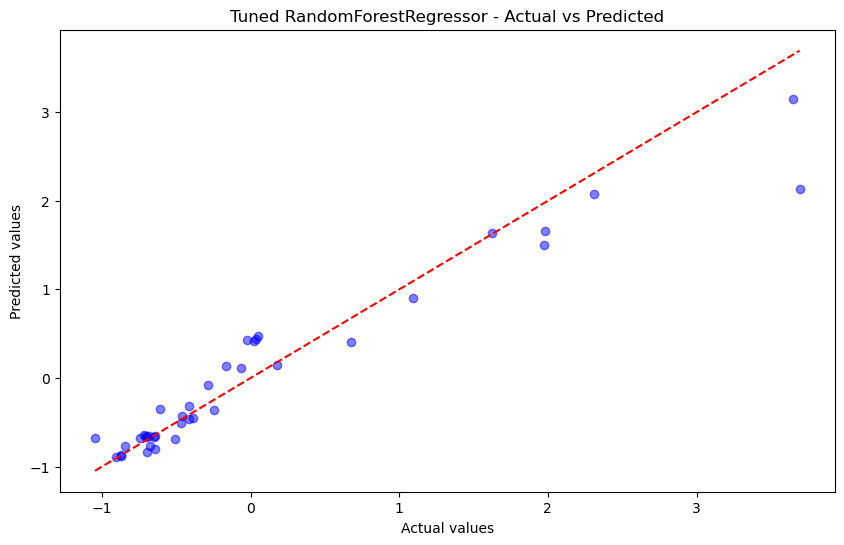

In [107]:
plot_actual_vs_predicted(y_test,y_pred_rf_tuned,"Tuned RandomForestRegressor")

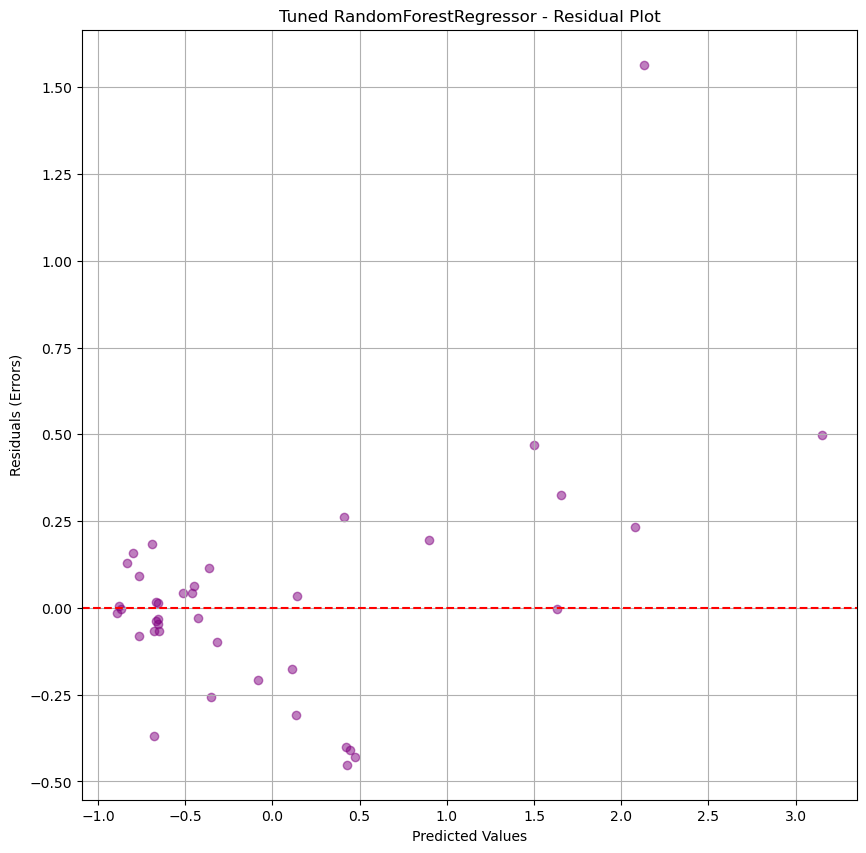

In [108]:
plot_residuals(y_test,y_pred_rf_tuned,"Tuned RandomForestRegressor")

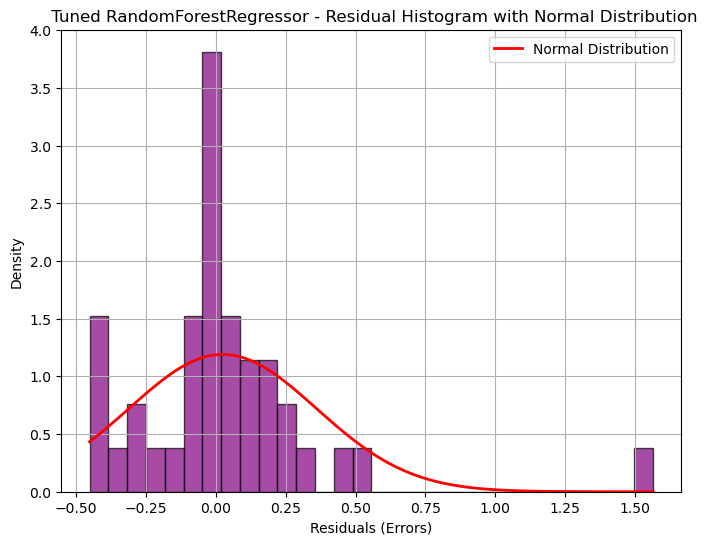

In [109]:

plot_residual_histogram(y_test,y_pred_rf_tuned," Tuned RandomForestRegressor")

╒══════════════════════════╤══════════════════╕
│ Feature                  │   Importance (%) │
╞══════════════════════════╪══════════════════╡
│ engine-size              │      13.6639     │
├──────────────────────────┼──────────────────┤
│ curb-weight              │      10.8487     │
├──────────────────────────┼──────────────────┤
│ city-mpg                 │       8.25317    │
├──────────────────────────┼──────────────────┤
│ combined_mpg             │       8.22115    │
├──────────────────────────┼──────────────────┤
│ horsepower               │       7.81633    │
├──────────────────────────┼──────────────────┤
│ highway-mpg              │       6.77847    │
├──────────────────────────┼──────────────────┤
│ num_cylinders            │       5.37187    │
├──────────────────────────┼──────────────────┤
│ width                    │       4.80105    │
├──────────────────────────┼──────────────────┤
│ wheel-base               │       4.12043    │
├──────────────────────────┼────────────

C:\Users\dell\AppData\Local\Temp\ipykernel_7864\3648721288.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance (%)", y="Feature", data=feature_importance, palette="viridis")


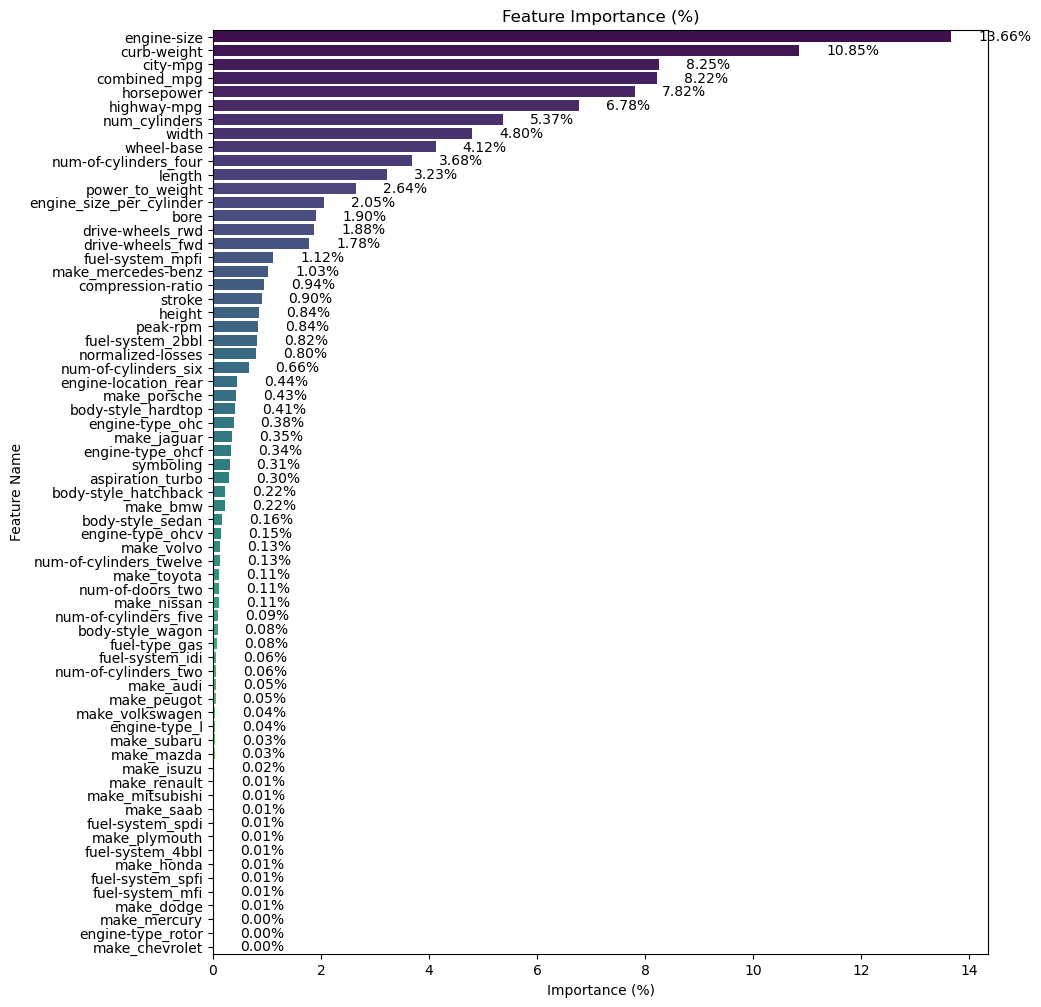

In [110]:
important_feature_rf=plot_feature_importance(best_rf_model,X_train.columns)

- Cross validation for tuned random forest


In [97]:
from sklearn.model_selection import cross_val_score

cv_mse = -cross_val_score(best_rf_model, X_train, y_train, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)

print("Cross-Validation MSE Scores:", cv_mse)
print("MSE standard deviation ",np.std(cv_mse))
print("Mean MSE:", np.mean(cv_mse))
print("Mean RMSE:", np.sqrt(np.mean(cv_mse)))


Cross-Validation MSE Scores: [0.06225874 0.0997847  0.04455089 0.03054124 0.12974158 0.08594429
 0.04381038 0.10196157 0.03188747 0.26813018]
MSE standard deviation  0.06741358901952416
Mean MSE: 0.08986110619621676
Mean RMSE: 0.2997684209455972


In [114]:
import pandas as pd


y_test_array = y_test.to_numpy().flatten() if hasattr(y_test, "to_numpy") else y_test.flatten()
y_pred_array = y_pred_rf_tuned.to_numpy().flatten() if hasattr(y_pred_rf_tuned, "to_numpy") else y_pred_rf_tuned.flatten()


df_comparison = pd.DataFrame({
    'Actual': y_test_array,
    'Predicted': y_pred_array
})

print(df_comparison)



      Actual  Predicted
0   2.309677   2.076083
1  -0.470370  -0.512205
2  -0.168787   0.138345
3   1.980438   1.655024
4  -0.699736  -0.830431
5  -0.701178  -0.654727
6  -0.508511  -0.691717
7  -0.385308  -0.447872
8  -0.702882  -0.665025
9   0.020604   0.420619
10 -0.642198  -0.655722
11  0.673970   0.411408
12 -0.412832  -0.315726
13  3.646553   3.148850
14 -0.871564  -0.867838
15 -1.046800  -0.679151
16 -0.066686   0.110352
17 -0.648620  -0.664948
18 -0.416502  -0.459061
19 -0.608514  -0.352304
20  0.047342   0.475457
21 -0.640756  -0.798796
22 -0.872744  -0.878397
23 -0.844827  -0.763780
24  3.693082   2.128182
25 -0.458574  -0.428544
26  0.036332   0.444843
27 -0.673523  -0.765288
28 -0.025924   0.425826
29  1.627084   1.630936
30 -0.905510  -0.889816
31 -0.686761  -0.654227
32  1.094037   0.898657
33 -0.714154  -0.646989
34  1.971002   1.502045
35 -0.246247  -0.361883
36 -0.287402  -0.080565
37  0.177097   0.143197
38 -0.743775  -0.677726


### Conclusion: Choosing the Best Model

#### **Notes**

- The **default RandomForest model** has **lower training MSE & higher R²**, but it **overfits** (performs worse in cross-validation).
- The **tuned RandomForest model** has **higher training error** but **better cross-validation results** (lower mean MSE, RMSE, and standard deviation).
- **Lower MSE standard deviation** in the tuned model means it is **more stable** across different dataset splits.
- **Compared to Decision Trees (both untuned and tuned), Random Forest achieved better accuracy and stability** in all cases.

**Final Choice**:  
The **Tuned RandomForestRegressor** is the best model as it balances performance and stability, making it **more reliable for real-world use**.
